# 01 - Exploratory Data Analysis (EDA)
## CheXpert: Chest X-Ray Disease Detection

Dette notebooked utforsker CheXpert-datasettet som vi skal bruke til å trene 
en CNN-modell for multi-label klassifisering av sykdommer i røntgenbilder.

**Datasett:** CheXpert-v1.0-small  
**Antall bilder:** 224,000 røntgenbilder  
**Antall klasser:** 14 mulige tilstander

In [1]:
import kagglehub
import os

# Last ned CheXpert datasettet
path = kagglehub.dataset_download("ashery/chexpert")
print("Data ligger på:", path)

Data ligger på: C:\Users\magne\.cache\kagglehub\datasets\ashery\chexpert\versions\1


## 1. Importer biblioteker
Vi bruker TensorFlow/Keras for deep learning, Pandas for databehandling, 
og Matplotlib/Seaborn for visualisering.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

print("Biblioteker lastet inn")

Biblioteker lastet inn


## 2. Last inn data
CheXpert kommer med en CSV-fil for trenings- og valideringsdata. 
Hver rad representerer ett bilde med tilhørende labels for 14 sykdommer.
Labels er kodet som:
- **1** = Positiv (sykdom til stede)
- **0** = Negativ (sykdom ikke til stede)  
- **-1** = Usikker
- **NaN** = Ikke nevnt i rapporten

In [3]:
# Last inn trenings- og valideringsdata
train_df = pd.read_csv(os.path.join(path, "train.csv"))
valid_df = pd.read_csv(os.path.join(path, "valid.csv"))

print("Treningsdata shape:", train_df.shape)
print("Valideringsdata shape:", valid_df.shape)
print("\nKolonner:", train_df.columns.tolist())
train_df.head()

Treningsdata shape: (223414, 19)
Valideringsdata shape: (234, 19)

Kolonner: ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


## 3. Fordeling av labels
Vi undersøker hvor mange positive, negative og usikre tilfeller 
det er per sykdom. Dette er viktig for å forstå klasseubalansen i datasettet.

In [4]:
# De 14 sykdommene vi skal klassifisere
conditions = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices'
]

# Tell positive (1), negative (0) og uncertain (-1) per sykdom
label_counts = train_df[conditions].apply(pd.Series.value_counts).T
label_counts.columns = ['Uncertain (-1)', 'Negative (0)', 'Positive (1)']
label_counts = label_counts.fillna(0).astype(int)

print(label_counts)

                            Uncertain (-1)  Negative (0)  Positive (1)
No Finding                               0             0         22381
Enlarged Cardiomediastinum           12403         21638         10798
Cardiomegaly                          8087         11116         27000
Lung Opacity                          5598          6599        105581
Lung Lesion                           1488          1270          9186
Edema                                12984         20726         52246
Consolidation                        27742         28097         14783
Pneumonia                            18770          2799          6039
Atelectasis                          33739          1328         33376
Pneumothorax                          3145         56341         19448
Pleural Effusion                     11628         35396         86187
Pleural Other                         2653           316          3523
Fracture                               642          2512          9040
Suppor

## 4. Visualisering av sykdomsfordeling
Et søylediagram gir oss et raskt overblikk over hvilke sykdommer som er vanligst og sjeldnest i treningsdataen.

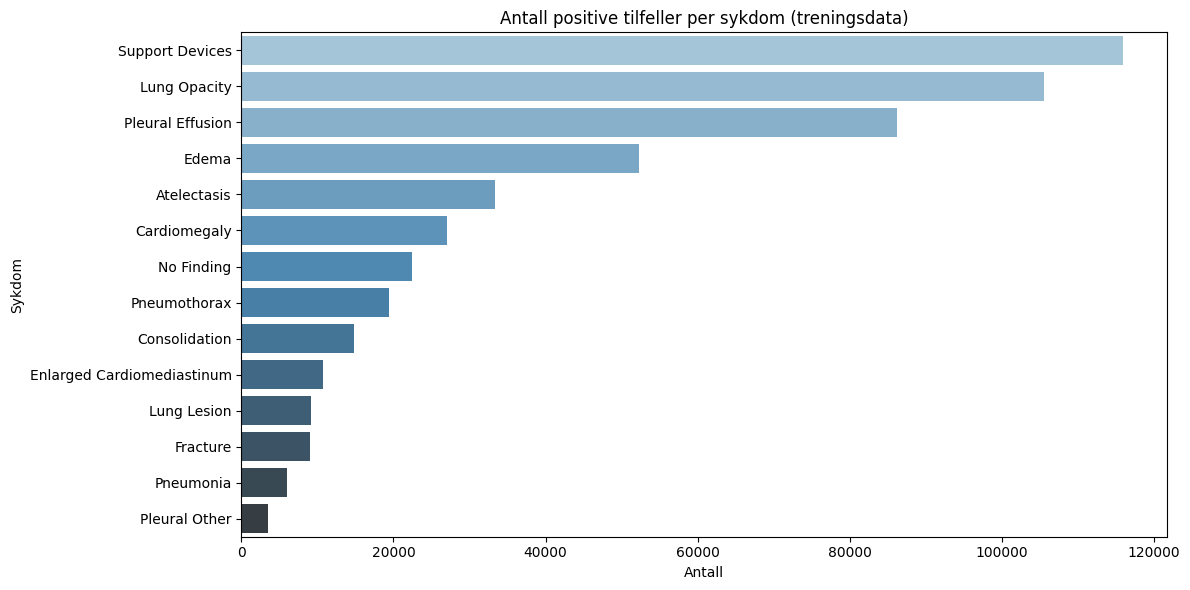

In [5]:
# Visualiser antall positive tilfeller per sykdom
positive_counts = (train_df[conditions] == 1).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=positive_counts.values, y=positive_counts.index, hue=positive_counts.index, legend=False, palette="Blues_d")
plt.title("Antall positive tilfeller per sykdom (treningsdata)")
plt.xlabel("Antall")
plt.ylabel("Sykdom")
plt.tight_layout()
plt.savefig("../results/figures/label_distribution.png")
plt.show()

## 5. Eksempler på røntgenbilder
Vi visualiserer noen tilfeldige bilder fra datasettet for å få 
en forståelse av bildekvalitet og hvordan sykdommene ser ut visuelt.

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\magne\\.cache\\kagglehub\\datasets\\ashery\\chexpert\\versions\\1\\CheXpert-v1.0-small/train/patient00082/study1/view1_frontal.jpg'

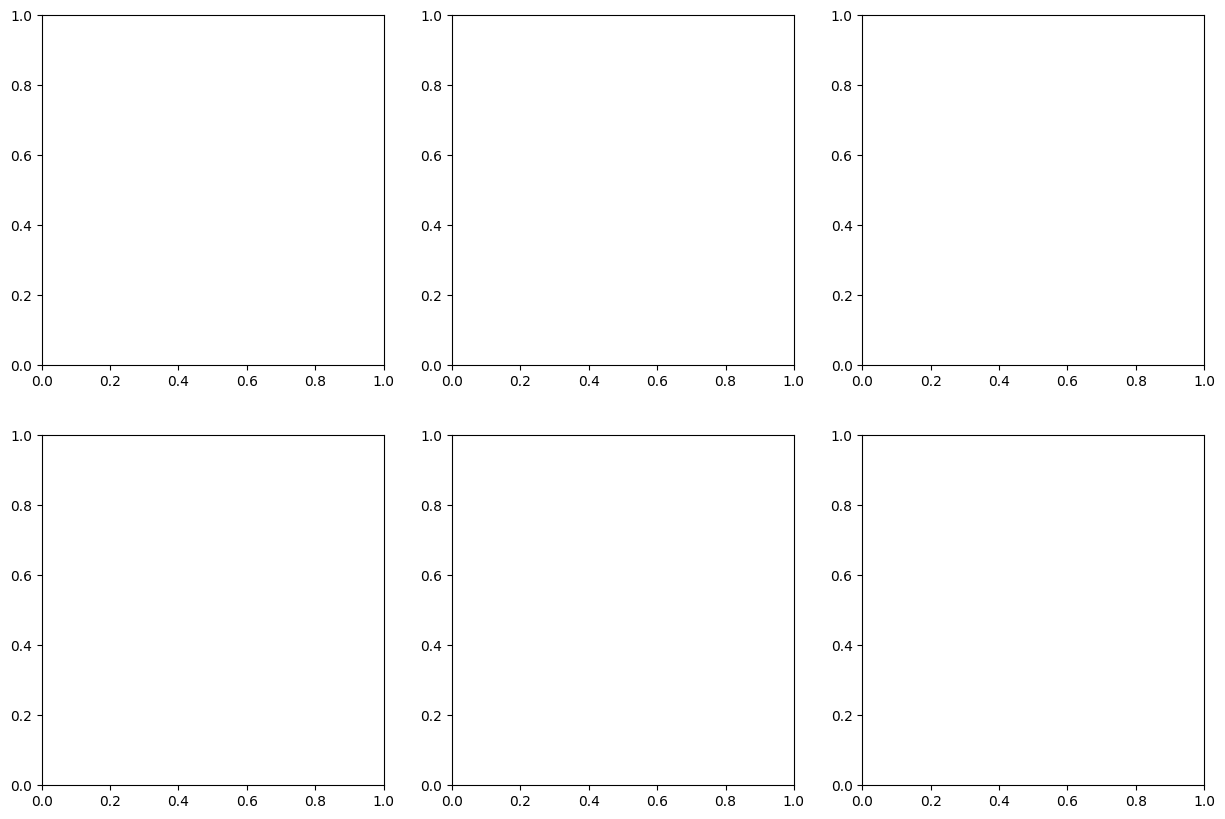

In [ ]:
# Vis 6 tilfeldige røntgenbilder
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sample = train_df.sample(6, random_state=42)

for i, (_, row) in enumerate(sample.iterrows()):
    # Fjern "CheXpert-v1.0-small/" fra stien
    relative_path = row['Path'].replace("CheXpert-v1.0-small/", "")
    img_path = os.path.join(path, relative_path)
    img = Image.open(img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    # Vis hvilke sykdommer bildet har
    labels = [c for c in conditions if row[c] == 1]
    axes[i].set_title('\n'.join(labels) if labels else 'No Finding', fontsize=8)

plt.suptitle("Eksempler på røntgenbilder fra CheXpert", fontsize=14)
plt.tight_layout()
plt.savefig("../results/figures/sample_images.png")
plt.show()

## 6. Manglende verdier
NaN-verdier i CheXpert betyr at en tilstand ikke ble nevnt i radiologirapporten. 
Dette er ikke det samme som negativ — det er en viktig distinksjon 
når vi later trener modellen.

## 7. Oppsummering
Nøkkeltall fra datasettet som gir oss et godt utgangspunkt 
før vi begynner å trene modeller.